In [ ]:
import pandas as pd
import numpy as np
!ls

sample_data


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/raw_data.csv', low_memory = False, compression='gzip')
len(df)

8381556

In [ ]:
df.head()

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng
0,2020-03-26 07:07:17,14626,12.313621,76.658195,12.287301,76.602280
1,2020-03-26 07:32:27,85490,12.943947,77.560745,12.954014,77.543770
2,2020-03-26 07:36:44,05408,12.899603,77.587300,12.934780,77.569950
3,2020-03-26 07:38:00,58940,12.918229,77.607544,12.968971,77.636375
4,2020-03-26 07:39:29,05408,12.899490,77.587270,12.934780,77.569950


In [ ]:
df[df.duplicated(subset=['ts','number'],keep=False)]

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng
235,2020-03-26 18:10:35,16795,12.967236,77.641594,13.014504,77.650856
236,2020-03-26 18:10:35,16795,12.967236,77.641594,13.014504,77.650856
407,2020-03-26 21:35:50,65856,12.917173,77.586400,12.913940,77.685280
408,2020-03-26 21:35:50,65856,12.917173,77.586400,12.913940,77.685280
443,2020-03-26 23:26:29,27554,12.933715,77.619300,12.938208,77.587520
...,...,...,...,...,...,...
8381231,2021-03-26 22:23:12,61636,12.975229,77.620370,13.017285,77.618200
8381245,2021-03-26 22:25:13,61636,12.975229,77.620370,13.017285,77.618200
8381246,2021-03-26 22:25:13,61636,12.975229,77.620370,13.017285,77.618200
8381248,2021-03-26 22:25:27,61636,12.975229,77.620370,13.017285,77.618200


In [ ]:
df.drop_duplicates(subset=['ts','number'], inplace = True, keep = 'last')

df.reset_index(inplace = True, drop = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8315498 entries, 0 to 8315497
Data columns (total 6 columns):
 #   Column    Dtype  
---  ------    -----  
 0   ts        object 
 1   number    object 
 2   pick_lat  float64
 3   pick_lng  float64
 4   drop_lat  float64
 5   drop_lng  float64
dtypes: float64(4), object(2)
memory usage: 380.7+ MB


In [ ]:
np.count_nonzero(df.isnull().values)

0

In [ ]:
df['number'] = pd.to_numeric(df['number'], errors = 'coerce')
np.count_nonzero(df.isnull().values)

116

In [ ]:
df.dropna(inplace = True)
len(df)

8315382

In [ ]:
df['number'] = pd.to_numeric(df['number'], errors = 'coerce', downcast='integer')
df['ts'] = pd.to_datetime(df['ts'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8315382 entries, 0 to 8315497
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   ts        datetime64[ns]
 1   number    int32         
 2   pick_lat  float64       
 3   pick_lng  float64       
 4   drop_lat  float64       
 5   drop_lng  float64       
dtypes: datetime64[ns](1), float64(4), int32(1)
memory usage: 412.4 MB


In [ ]:
df['hour'] = df['ts'].dt.hour
df['mins'] = df['ts'].dt.minute
df['day'] = df['ts'].dt.day
df['month'] = df['ts'].dt.month
df['year'] = df['ts'].dt.year
df['dayofweek'] = df['ts'].dt.dayofweek

In [ ]:
ression = 'gzidf.to_csv('/content/drive/MyDrive/raw_data.csv',index = False, compp')

In [ ]:
df

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,mins,day,month,year,dayofweek
0,2020-03-26 07:07:17,14626,12.313621,76.658195,12.287301,76.602280,7,7,26,3,2020,3
1,2020-03-26 07:32:27,85490,12.943947,77.560745,12.954014,77.543770,7,32,26,3,2020,3
2,2020-03-26 07:36:44,5408,12.899603,77.587300,12.934780,77.569950,7,36,26,3,2020,3
3,2020-03-26 07:38:00,58940,12.918229,77.607544,12.968971,77.636375,7,38,26,3,2020,3
4,2020-03-26 07:39:29,5408,12.899490,77.587270,12.934780,77.569950,7,39,26,3,2020,3
...,...,...,...,...,...,...,...,...,...,...,...,...
8315493,2021-03-26 23:55:24,50410,12.907856,77.557870,12.954270,77.530785,23,55,26,3,2021,4
8315494,2021-03-26 23:58:15,12580,12.981010,77.694450,12.969070,77.704280,23,58,26,3,2021,4
8315495,2021-03-26 22:11:20,72339,12.924252,77.650520,12.905820,77.630570,22,11,26,3,2021,4
8315496,2021-03-26 22:12:30,72339,12.924252,77.650520,12.905820,77.630570,22,12,26,3,2021,4


In [ ]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from geopy.geocoders import Nominatim
import time
geolocator = Nominatim(user_agent="OLABikes")
!ls

drive  sample_data


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/raw_data.csv', compression = 'gzip')

In [ ]:
df['ts'] = pd.to_datetime(df['ts'])
df.sort_values(by = ['number','ts'], inplace = True)
df.reset_index(inplace = True)

In [ ]:
df['booking_timestamp'] = df.ts.values.astype(np.int64)// 10 ** 9

In [ ]:
df.head(50)

,index,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,mins,day,month,year,dayofweek,booking_timestamp
0,2374378,2020-10-10 07:34:16,-1,12.975773,77.571070,12.878468,77.445330,7,34,10,10,2020,5,1602315256
1,2405894,2020-10-11 08:23:42,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404622
2,2405895,2020-10-11 08:23:50,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404630
3,2405896,2020-10-11 08:23:51,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404631
4,2405897,2020-10-11 08:23:54,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404634
5,2405898,2020-10-11 08:23:56,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404636
6,2406076,2020-10-11 11:57:17,-1,12.960213,77.587460,12.930824,77.609610,11,57,11,10,2020,6,1602417437
7,2406077,2020-10-11 11:57:31,-1,12.960213,77.587460,12.930824,77.609610,11,57,11,10,2020,6,1602417451
8,2500477,2020-10-16 17:51:07,-1,12.924353,77.549410,12.932216,77.581825,17,51,16,10,2020,4,1602870667
9,2500478,2020-10-16 17:51:25,-1,12.924353,77.549410,12.932216,77.581825,17,51,16,10,2020,4,1602870685


In [ ]:
df['shift_booking_ts'] = df.groupby('number')['booking_timestamp'].shift(1)
df['shift_booking_ts'].fillna(0, inplace = True)

In [ ]:
df['shift_booking_ts'] = df['shift_booking_ts'].astype('int64')

In [ ]:
df['booking_time_diff_hr'] = round((df['booking_timestamp'] - df['shift_booking_ts'])//3600)
df['booking_time_diff_min'] = round((df['booking_timestamp'] - df['shift_booking_ts'])//60)

In [ ]:
df['booking_time_diff_min'].value_counts().to_dict()

{0: 2801749,
 1: 799993,
 2: 307831,
 3: 167954,
 4: 109141,
 5: 77918,
 6: 60416,
 7: 48342,
 8: 40404,
 9: 34407,
 10: 29977,
 11: 26091,
 12: 23336,
 13: 20839,
 14: 18945,
 15: 16872,
 16: 15467,
 17: 13885,
 18: 12804,
 19: 11870,
 20: 10869,
 21: 10105,
 22: 9397,
 23: 8810,
 24: 8185,
 25: 7752,
 26: 7255,
 27: 6898,
 28: 6610,
 29: 6263,
 30: 6034,
 31: 5773,
 1439: 5725,
 1440: 5712,
 32: 5702,
 1438: 5489,
 1437: 5402,
 1441: 5391,
 33: 5349,
 1442: 5303,
 1443: 5178,
 34: 5094,
 1436: 5076,
 35: 4965,
 1435: 4962,
 36: 4907,
 1444: 4861,
 38: 4780,
 37: 4757,
 1434: 4724,
 1433: 4662,
 1445: 4581,
 39: 4542,
 40: 4464,
 41: 4416,
 1432: 4407,
 1446: 4401,
 42: 4292,
 43: 4213,
 1431: 4170,
 44: 4133,
 1447: 4123,
 1430: 4038,
 45: 4016,
 1448: 3993,
 47: 3989,
 46: 3977,
 48: 3931,
 50: 3872,
 1449: 3838,
 1429: 3836,
 51: 3817,
 49: 3807,
 53: 3693,
 52: 3659,
 1428: 3644,
 54: 3643,
 55: 3624,
 1427: 3611,
 56: 3577,
 59: 3563,
 1450: 3552,
 1426: 3521,
 63: 3449,
 57: 344

In [ ]:
df['booking_time_diff_hr'].value_counts().to_dict()

{0: 4849856,
 1: 164914,
 23: 152962,
 24: 132454,
 2: 118199,
 9: 104854,
 3: 90789,
 10: 86794,
 8: 84454,
 14: 83715,
 13: 80005,
 4: 71379,
 11: 69332,
 12: 69267,
 7: 64610,
 15: 61892,
 5: 58059,
 22: 56709,
 6: 55287,
 16: 45075,
 21: 42289,
 47: 41525,
 25: 38067,
 48: 36781,
 20: 36559,
 17: 36124,
 19: 33701,
 18: 32710,
 71: 27538,
 72: 24658,
 26: 23932,
 46: 20902,
 27: 17593,
 45: 17142,
 49: 16426,
 38: 16319,
 95: 15844,
 37: 15186,
 39: 15048,
 44: 14897,
 96: 14258,
 43: 14004,
 28: 13903,
 40: 13586,
 70: 13131,
 36: 13019,
 42: 12926,
 41: 12516,
 50: 11945,
 35: 11789,
 29: 11770,
 34: 11479,
 33: 11356,
 119: 10863,
 62: 10769,
 73: 10731,
 32: 10583,
 30: 10279,
 69: 10150,
 31: 9997,
 120: 9641,
 63: 9561,
 61: 9401,
 51: 9313,
 68: 8957,
 94: 8381,
 143: 8335,
 167: 8252,
 64: 8089,
 60: 7865,
 67: 7802,
 52: 7755,
 144: 7645,
 74: 7590,
 168: 7571,
 66: 7370,
 65: 7293,
 97: 7220,
 93: 6805,
 59: 6594,
 53: 6488,
 58: 6294,
 118: 6171,
 75: 6029,
 57: 5957,
 5

In [ ]:
len(df)

8315382

In [ ]:
df = df[~((df.duplicated(subset=['number','pick_lat','pick_lng'],keep=False)) & (df.booking_time_diff_hr<=1))]

In [ ]:
len(df)

4335828

In [ ]:
df.to_csv('/content/drive/MyDrive/raw_data.csv',index = False, compression = 'gzip')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/raw_data.csv', compression = 'gzip')

In [ ]:
print("Number of rides booked by same customer within 8mins time: {}".format(len(df[(df.booking_time_diff_min<8)])))
df = df[(df.booking_time_diff_min>=8)]

Number of rides booked by same customer within 8mins time: 611891


In [ ]:
def geodestic_distance(pick_lat, pick_lng, drop_lat, drop_lng):
    return round(geodesic((pick_lat, pick_lng), (drop_lat, drop_lng)).miles*1.60934,2)
df['geodesic_distance'] = np.vectorize(geodestic_distance)(df['pick_lat'],df['pick_lng'],df['drop_lat'],df['drop_lng'])

In [ ]:
df[df['geodesic_distance']<=0.5]['geodesic_distance'].value_counts()

0.00    6619
0.01    2492
0.02    2011
0.03    1371
0.50    1210
0.04    1090
0.47    1076
0.49    1067
0.48    1064
0.46    1056
0.44     895
0.45     881
0.05     877
0.43     845
0.41     764
0.39     758
0.06     752
0.42     748
0.40     746
0.38     682
0.37     675
0.07     655
0.36     641
0.33     594
0.08     592
0.34     585
0.35     582
0.09     549
0.32     542
0.31     530
0.10     498
0.11     492
0.30     490
0.29     476
0.12     457
0.28     447
0.26     439
0.27     432
0.14     410
0.17     408
0.21     404
0.20     397
0.24     391
0.22     390
0.13     384
0.18     369
0.23     368
0.15     364
0.19     355
0.25     342
0.16     339
Name: geodesic_distance, dtype: int64

In [ ]:
print("Number of Rides Requests less than 50meters: {}".format(len(df[df.geodesic_distance<=0.05])))

Number of Rides Requests less than 50meters: 14460


In [ ]:
df = df[df.geodesic_distance>0.05]
df

,index,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,mins,day,month,year,dayofweek,booking_timestamp,shift_booking_ts,booking_time_diff_hr,booking_time_diff_min,geodesic_distance
0,2374378,2020-10-10 07:34:16,-1,12.975773,77.571070,12.878468,77.445330,7,34,10,10,2020,5,1602315256,0,445087,26705254,17.38
1,2405894,2020-10-11 08:23:42,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404622,1602315256,24,1489,4.06
2,2406076,2020-10-11 11:57:17,-1,12.960213,77.587460,12.930824,77.609610,11,57,11,10,2020,6,1602417437,1602404636,3,213,4.04
3,2500477,2020-10-16 17:51:07,-1,12.924353,77.549410,12.932216,77.581825,17,51,16,10,2020,4,1602870667,1602417451,125,7553,3.62
4,2694503,2020-10-30 09:00:44,-1,12.945731,77.622500,12.973030,77.616840,9,0,30,10,2020,4,1604048444,1602870685,327,19629,3.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335823,5768115,2021-02-12 19:37:11,99999,13.029848,77.593400,13.063751,77.589850,19,37,12,2,2021,4,1613158631,1613068718,24,1498,3.77
4335824,6102760,2021-02-19 20:43:25,99999,13.029296,77.592580,12.927923,77.627106,20,43,19,2,2021,4,1613767405,1613158631,169,10146,11.82
4335825,6137206,2021-02-20 17:34:45,99999,12.907576,77.600685,12.925874,77.607620,17,34,20,2,2021,5,1613842485,1613767405,20,1251,2.16
4335826,6555089,2021-02-27 08:26:23,99999,12.956665,77.521870,12.948099,77.562990,8,26,27,2,2021,5,1614414383,1613842485,158,9531,4.56


In [ ]:
len(df)

3709477

In [ ]:
df.to_csv('/content/drive/MyDrive/raw_data.csv',index = False, compression = 'gzip')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/raw_data.csv', compression = 'gzip')
location = geolocator.geocode("India")
location.raw

{'place_id': 246884012,
 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright',
 'osm_type': 'relation',
 'osm_id': 304716,
 'lat': '22.3511148',
 'lon': '78.6677428',
 'class': 'boundary',
 'type': 'administrative',
 'place_rank': 4,
 'importance': 0.847689135880987,
 'addresstype': 'country',
 'name': 'India',
 'display_name': 'India',
 'boundingbox': ['6.5531169', '35.6745457', '67.9544415', '97.3955610']}

In [ ]:
df

,index,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,mins,day,month,year,dayofweek,booking_timestamp,shift_booking_ts,booking_time_diff_hr,booking_time_diff_min,geodesic_distance
0,2374378,2020-10-10 07:34:16,-1,12.975773,77.571070,12.878468,77.445330,7,34,10,10,2020,5,1602315256,0,445087,26705254,17.38
1,2405894,2020-10-11 08:23:42,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404622,1602315256,24,1489,4.06
2,2406076,2020-10-11 11:57:17,-1,12.960213,77.587460,12.930824,77.609610,11,57,11,10,2020,6,1602417437,1602404636,3,213,4.04
3,2500477,2020-10-16 17:51:07,-1,12.924353,77.549410,12.932216,77.581825,17,51,16,10,2020,4,1602870667,1602417451,125,7553,3.62
4,2694503,2020-10-30 09:00:44,-1,12.945731,77.622500,12.973030,77.616840,9,0,30,10,2020,4,1604048444,1602870685,327,19629,3.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3709472,5768115,2021-02-12 19:37:11,99999,13.029848,77.593400,13.063751,77.589850,19,37,12,2,2021,4,1613158631,1613068718,24,1498,3.77
3709473,6102760,2021-02-19 20:43:25,99999,13.029296,77.592580,12.927923,77.627106,20,43,19,2,2021,4,1613767405,1613158631,169,10146,11.82
3709474,6137206,2021-02-20 17:34:45,99999,12.907576,77.600685,12.925874,77.607620,17,34,20,2,2021,5,1613842485,1613767405,20,1251,2.16
3709475,6555089,2021-02-27 08:26:23,99999,12.956665,77.521870,12.948099,77.562990,8,26,27,2,2021,5,1614414383,1613842485,158,9531,4.56


In [ ]:
df[(df.pick_lat<=6.2325274) | (df.pick_lat>=35.6745457) | (df.pick_lng<=68.1113787) | (df.pick_lng>=97.395561) | (df.drop_lat<=6.2325274) | (df.drop_lat>=35.6745457) | (df.drop_lng<=68.1113787) | (df.drop_lng>=97.395561)]

,index,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,mins,day,month,year,dayofweek,booking_timestamp,shift_booking_ts,booking_time_diff_hr,booking_time_diff_min,geodesic_distance
4266,742031,2020-06-22 07:19:06,80,12.926255,77.616400,0.000000e+00,0.000000e+00,7,19,22,6,2020,0,1592810346,1590934080,521,31271,8674.57
13118,2502259,2020-10-16 21:52:28,297,12.958342,77.517876,3.890229e+00,-3.344596e+01,21,52,16,10,2020,4,1602885148,1602884658,0,8,12181.79
14555,4344697,2021-01-07 13:17:11,345,12.824208,77.684840,5.347187e+01,-1.021332e+02,13,17,7,1,2021,3,1610025431,1609843045,50,3039,12658.48
20669,8297478,2021-03-26 20:16:01,485,12.932975,77.536230,2.819774e+01,1.129942e+02,20,16,26,3,2021,4,1616789761,1616697903,25,1530,4043.95
26884,1786595,2020-09-09 09:36:43,641,12.896367,77.623800,0.000000e+00,0.000000e+00,9,36,9,9,2020,2,1599644203,0,444345,26660736,8675.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3664741,1985134,2020-09-21 14:40:51,98929,12.852040,77.675490,1.400000e-45,1.400000e-45,14,40,21,9,2020,0,1600699251,1600355752,95,5724,8680.58
3670580,834555,2020-07-02 08:40:16,99078,12.924925,77.606125,3.772864e+01,-8.920558e+01,8,40,2,7,2020,3,1593679216,1591804249,520,31249,14231.82
3671696,2331458,2020-10-06 18:12:35,99104,12.928082,77.603350,1.376042e+01,1.004980e+02,18,12,6,10,2020,1,1602007955,1601834214,48,2895,2481.04
3681558,2747830,2020-11-02 18:57:02,99379,12.984081,77.593330,0.000000e+00,0.000000e+00,18,57,2,11,2020,0,1604343422,1604309746,9,561,8672.37


In [ ]:
df.reset_index(inplace = True, drop = True)
outside_India = df[(df.pick_lat<=6.2325274) | (df.pick_lat>=35.6745457) | (df.pick_lng<=68.1113787) | (df.pick_lng>=97.395561) | (df.drop_lat<=6.2325274) | (df.drop_lat>=35.6745457) | (df.drop_lng<=68.1113787) | (df.drop_lng>=97.395561)]
df = df[~df.index.isin(outside_India.index)].reset_index(drop = True)
df

,index,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,mins,day,month,year,dayofweek,booking_timestamp,shift_booking_ts,booking_time_diff_hr,booking_time_diff_min,geodesic_distance
0,2374378,2020-10-10 07:34:16,-1,12.975773,77.571070,12.878468,77.445330,7,34,10,10,2020,5,1602315256,0,445087,26705254,17.38
1,2405894,2020-10-11 08:23:42,-1,12.930813,77.609530,12.960320,77.587210,8,23,11,10,2020,6,1602404622,1602315256,24,1489,4.06
2,2406076,2020-10-11 11:57:17,-1,12.960213,77.587460,12.930824,77.609610,11,57,11,10,2020,6,1602417437,1602404636,3,213,4.04
3,2500477,2020-10-16 17:51:07,-1,12.924353,77.549410,12.932216,77.581825,17,51,16,10,2020,4,1602870667,1602417451,125,7553,3.62
4,2694503,2020-10-30 09:00:44,-1,12.945731,77.622500,12.973030,77.616840,9,0,30,10,2020,4,1604048444,1602870685,327,19629,3.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3708830,5768115,2021-02-12 19:37:11,99999,13.029848,77.593400,13.063751,77.589850,19,37,12,2,2021,4,1613158631,1613068718,24,1498,3.77
3708831,6102760,2021-02-19 20:43:25,99999,13.029296,77.592580,12.927923,77.627106,20,43,19,2,2021,4,1613767405,1613158631,169,10146,11.82
3708832,6137206,2021-02-20 17:34:45,99999,12.907576,77.600685,12.925874,77.607620,17,34,20,2,2021,5,1613842485,1613767405,20,1251,2.16
3708833,6555089,2021-02-27 08:26:23,99999,12.956665,77.521870,12.948099,77.562990,8,26,27,2,2021,5,1614414383,1613842485,158,9531,4.56


In [ ]:
print("Number of Good Ride Requests: {}".format(len(df)))

Number of Good Ride Requests: 3708835


In [ ]:
pck_outside_bng = df[(df.pick_lat<=12.8340125) | (df.pick_lat>=13.1436649) | (df.pick_lng<=77.4601025) | (df.pick_lng>=77.7840515)]
drp_outside_bng = df[(df.drop_lat<=12.8340125) | (df.drop_lat>=13.1436649) | (df.drop_lng<=77.4601025) | (df.drop_lng>=77.7840515)]
print("Number of Pickup Requests Outside Bangalore: ",len(pck_outside_bng))
print("Number of Customers pickup outside Bangalore: ",len(np.unique(pck_outside_bng['number'].values)))

print("Number of Drops Requests Outside Bangalore: ",len(drp_outside_bng))
print("Number of Customers Drop outside Bangalore: ",len(np.unique(drp_outside_bng['number'].values)))

Number of Pickup Requests Outside Bangalore:  155908
Number of Customers pickup outside Bangalore:  20473
Number of Drops Requests Outside Bangalore:  167338
Number of Customers Drop outside Bangalore:  26878


In [ ]:
pck_outside_KA = df[(df.pick_lat<=11.5945587) | (df.pick_lat>=18.4767308) | (df.pick_lng<=74.0543908) | (df.pick_lng>=78.588083)]
drp_outside_KA = df[(df.drop_lat<=11.5945587) | (df.drop_lat>=18.4767308) | (df.drop_lng<=74.0543908) | (df.drop_lng>=78.588083)]
print("Pickups Outisde KA: {} \nDrop outside KA: {}".format(len(pck_outside_KA),len(drp_outside_KA)))
print("Number of Customers Drop outside KA: ",len(np.unique(drp_outside_KA['number'].values)))
print("Number of Customers pickup outside KA: ",len(np.unique(pck_outside_KA['number'].values)))

Pickups Outisde KA: 38807 
Drop outside KA: 39585
Number of Customers Drop outside KA:  6917
Number of Customers pickup outside KA:  6302


In [ ]:
total_ride_outside_KA = df[(df.pick_lat<=11.5945587) | (df.pick_lat>=18.4767308) | (df.pick_lng<=74.0543908) | (df.pick_lng>=78.588083)]

In [ ]:
print("Total Ride Outside Karnataka: {}".format(len(total_ride_outside_KA)))

Total Ride Outside Karnataka: 38807


In [ ]:
suspected_bad_rides = total_ride_outside_KA[total_ride_outside_KA.geodesic_distance > 500]
suspected_bad_rides

,index,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,hour,mins,day,month,year,dayofweek,booking_timestamp,shift_booking_ts,booking_time_diff_hr,booking_time_diff_min,geodesic_distance
49014,4159408,2020-12-31 18:24:14,1079,23.059650,72.592384,12.985226,77.567955,18,24,31,12,2020,3,1609439054,1603531640,1640,98456,1232.88
233031,6467708,2021-02-25 19:32:52,6081,20.351206,85.818540,12.966769,77.610850,19,32,25,2,2021,3,1614281572,1614082106,55,3324,1197.08
456961,4746416,2021-01-21 20:15:35,12058,22.586773,88.409000,13.368601,77.681010,20,15,21,1,2021,3,1611260135,1611172353,24,1463,1525.81
490486,4388986,2021-01-09 08:57:54,12896,23.028847,72.601420,12.929365,77.556920,8,57,9,1,2021,5,1610182674,1610143979,10,644,1234.54
524431,4209869,2021-01-03 21:00:14,13869,21.149794,82.782000,12.903941,77.601280,21,0,3,1,2021,6,1609707614,1609240758,129,7780,1066.00
631174,975581,2020-07-18 13:24:48,16969,23.235060,77.434000,18.499937,73.869270,13,24,18,7,2020,5,1595078688,1595077882,0,13,642.13
1030868,2838588,2020-11-06 12:00:26,27487,23.231668,77.390040,12.962337,77.701540,12,0,6,11,2020,4,1604664026,1600878199,1051,63097,1137.12
1172124,3476061,2020-12-01 19:09:18,31390,25.615124,85.168010,28.518116,77.206210,19,9,1,12,2020,1,1606849758,1606061360,218,13139,852.51
1210067,3892966,2020-12-22 00:34:36,32390,28.440247,77.078964,12.908864,77.662890,0,34,22,12,2020,1,1608597276,1607627950,269,16155,1720.67
1453698,4714547,2021-01-20 15:20:43,38627,28.505898,77.096200,12.710525,77.691130,15,20,20,1,2021,2,1611156043,1610913265,67,4046,1749.91


In [ ]:
df = df[~df.index.isin(suspected_bad_rides.index)].reset_index(drop = True)
print("Number of Good Ride Requests: {}".format(len(df)))

Number of Good Ride Requests: 3708810


In [ ]:
dataset = df[['ts', 'number', 'pick_lat','pick_lng','drop_lat','drop_lng','geodesic_distance','hour','mins','day','month','year','dayofweek','booking_timestamp','booking_time_diff_hr', 'booking_time_diff_min']]
dataset.to_csv('/content/drive/MyDrive/raw_data.csv',index = False, compression = 'gzip')

In [ ]:
!pip install gpxpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from copy import deepcopy
from matplotlib import pyplot as plt
from sklearn.cluster import MiniBatchKMeans, KMeans
import gpxpy.geo
from datetime import datetime, timedelta
from joblib import dump, load

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/raw_data.csv', compression = 'gzip')

In [ ]:
len(df)

3708810

In [ ]:
coord = df[["pick_lat", "pick_lng"]].values
neighbors = []

In [ ]:
def min_distance(regionCenters, totalClusters):
    good_points = 0
    bad_points = 0
    less_dist = []
    more_dist = []
    min_distance = np.inf  #any big number can be given here
    for i in range(totalClusters):
        good_points = 0
        bad_points = 0
        for j in range(totalClusters):
            if j != i:
                distance = gpxpy.geo.haversine_distance(latitude_1 = regionCenters[i][0], longitude_1 = regionCenters[i][1], latitude_2 = regionCenters[j][0], longitude_2 = regionCenters[j][1])
                distance = distance/(1.60934*1000)   #distance from meters to miles
                min_distance = min(min_distance, distance) #it will return minimum of "min_distance, distance".
                if distance < 2:
                    good_points += 1
                else:
                    bad_points += 1
        less_dist.append(good_points)
        more_dist.append(bad_points)
    print("On choosing a cluster size of {}".format(totalClusters))
    print("Avg. Number clusters within vicinity where inter cluster distance < 2 miles is {}".format(np.ceil(sum(less_dist)/len(less_dist))))
    print("Avg. Number clusters outside of vicinity where inter cluster distance > 2 miles is {}".format(np.ceil(sum(more_dist)/len(more_dist))))
    print("Minimum distance between any two clusters = {}".format(min_distance))
    print("-"*10)

def makingRegions(noOfRegions):
    regions = MiniBatchKMeans(n_clusters = noOfRegions, batch_size = 10000, random_state = 5).fit(coord)
    regionCenters = regions.cluster_centers_
    totalClusters = len(regionCenters)
    return regionCenters, totalClusters

In [ ]:
startTime = datetime.now()
for i in range(10, 100, 10):
    regionCenters, totalClusters = makingRegions(i)
    min_distance(regionCenters, totalClusters)
print("Time taken = "+str(datetime.now() - startTime))

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


On choosing a cluster size of 10
Avg. Number clusters within vicinity where inter cluster distance < 2 miles is 0.0
Avg. Number clusters outside of vicinity where inter cluster distance > 2 miles is 9.0
Minimum distance between any two clusters = 2.059160613886048
----------


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


On choosing a cluster size of 20
Avg. Number clusters within vicinity where inter cluster distance < 2 miles is 1.0
Avg. Number clusters outside of vicinity where inter cluster distance > 2 miles is 19.0
Minimum distance between any two clusters = 1.1984054039400929
----------


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


...

On choosing a cluster size of 70
Avg. Number clusters within vicinity where inter cluster distance < 2 miles is 4.0
Avg. Number clusters outside of vicinity where inter cluster distance > 2 miles is 66.0
Minimum distance between any two clusters = 0.5701232099151515
----------


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


On choosing a cluster size of 80
Avg. Number clusters within vicinity where inter cluster distance < 2 miles is 5.0
Avg. Number clusters outside of vicinity where inter cluster distance > 2 miles is 75.0
Minimum distance between any two clusters = 0.6310575900407485
----------


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


On choosing a cluster size of 90
Avg. Number clusters within vicinity where inter cluster distance < 2 miles is 6.0
Avg. Number clusters outside of vicinity where inter cluster distance > 2 miles is 84.0
Minimum distance between any two clusters = 0.6239297839465191
----------
Time taken = 0:00:33.301137


In [ ]:
coord = df[["pick_lat", "pick_lng"]].values
regions = MiniBatchKMeans(n_clusters = 50, batch_size = 10000, random_state = 0).fit(coord)
df["pickup_cluster"] = regions.predict(df[["pick_lat", "pick_lng"]])

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


In [ ]:
df

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,geodesic_distance,hour,mins,day,month,year,dayofweek,booking_timestamp,booking_time_diff_hr,booking_time_diff_min,pickup_cluster
0,2020-10-10 07:34:16,-1,12.975773,77.571070,12.878468,77.445330,17.38,7,34,10,10,2020,5,1602315256,445087,26705254,38
1,2020-10-11 08:23:42,-1,12.930813,77.609530,12.960320,77.587210,4.06,8,23,11,10,2020,6,1602404622,24,1489,0
2,2020-10-11 11:57:17,-1,12.960213,77.587460,12.930824,77.609610,4.04,11,57,11,10,2020,6,1602417437,3,213,40
3,2020-10-16 17:51:07,-1,12.924353,77.549410,12.932216,77.581825,3.62,17,51,16,10,2020,4,1602870667,125,7553,31
4,2020-10-30 09:00:44,-1,12.945731,77.622500,12.973030,77.616840,3.08,9,0,30,10,2020,4,1604048444,327,19629,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3708805,2021-02-12 19:37:11,99999,13.029848,77.593400,13.063751,77.589850,3.77,19,37,12,2,2021,4,1613158631,24,1498,39
3708806,2021-02-19 20:43:25,99999,13.029296,77.592580,12.927923,77.627106,11.82,20,43,19,2,2021,4,1613767405,169,10146,39
3708807,2021-02-20 17:34:45,99999,12.907576,77.600685,12.925874,77.607620,2.16,17,34,20,2,2021,5,1613842485,20,1251,12
3708808,2021-02-27 08:26:23,99999,12.956665,77.521870,12.948099,77.562990,4.56,8,26,27,2,2021,5,1614414383,158,9531,41


In [ ]:
dump(regions, '/content/drive/MyDrive/raw_data.csv', compress = 3)

['/content/drive/MyDrive/raw_data.csv']

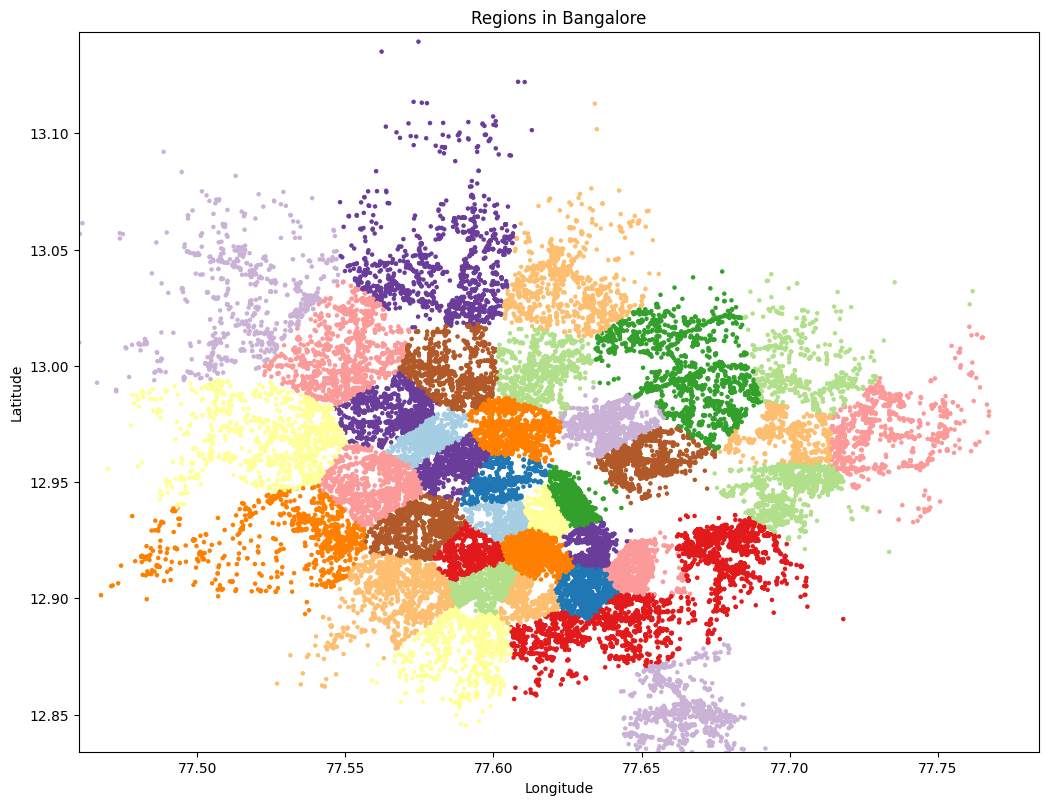

In [ ]:
bangalore_latitude_range = (12.8340125, 13.1436649)
bangalore_longitude_range = (77.4601025, 77.7840515)
fig = plt.figure()
ax = fig.add_axes([0,0,1.5,1.5])
ax.scatter(x = df.pick_lng.values[:100000], y = df.pick_lat.values[:100000], c = df.pickup_cluster.values[:100000], cmap = "Paired", s = 5)
ax.set_xlim(77.4601025, 77.7840515)
ax.set_ylim(12.8340125, 13.1436649)
ax.set_title("Regions in Bangalore")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

In [ ]:
df.head()

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,geodesic_distance,hour,mins,day,month,year,dayofweek,booking_timestamp,booking_time_diff_hr,booking_time_diff_min,pickup_cluster
0,2020-10-10 07:34:16,-1,12.975773,77.57107,12.878468,77.445330,17.38,7,34,10,10,2020,5,1602315256,445087,26705254,38
1,2020-10-11 08:23:42,-1,12.930813,77.60953,12.960320,77.587210,4.06,8,23,11,10,2020,6,1602404622,24,1489,0
2,2020-10-11 11:57:17,-1,12.960213,77.58746,12.930824,77.609610,4.04,11,57,11,10,2020,6,1602417437,3,213,40
3,2020-10-16 17:51:07,-1,12.924353,77.54941,12.932216,77.581825,3.62,17,51,16,10,2020,4,1602870667,125,7553,31
4,2020-10-30 09:00:44,-1,12.945731,77.62250,12.973030,77.616840,3.08,9,0,30,10,2020,4,1604048444,327,19629,16


In [ ]:
def round_timestamp_30interval(x):
    if type(x)==str:
        x = datetime.strptime(x, '%Y-%m-%d %H:%M:%S')
    return x- timedelta(minutes=x.minute%30, seconds=x.second, microseconds=x.microsecond)

df['ts'] = np.vectorize(round_timestamp_30interval)(df['ts'])

In [ ]:
dataset = deepcopy(df)
dataset.ts = pd.to_datetime(dataset.ts)
dataset

,ts,number,pick_lat,pick_lng,drop_lat,drop_lng,geodesic_distance,hour,mins,day,month,year,dayofweek,booking_timestamp,booking_time_diff_hr,booking_time_diff_min,pickup_cluster
0,2020-10-10 07:30:00,-1,12.975773,77.571070,12.878468,77.445330,17.38,7,34,10,10,2020,5,1602315256,445087,26705254,38
1,2020-10-11 08:00:00,-1,12.930813,77.609530,12.960320,77.587210,4.06,8,23,11,10,2020,6,1602404622,24,1489,0
2,2020-10-11 11:30:00,-1,12.960213,77.587460,12.930824,77.609610,4.04,11,57,11,10,2020,6,1602417437,3,213,40
3,2020-10-16 17:30:00,-1,12.924353,77.549410,12.932216,77.581825,3.62,17,51,16,10,2020,4,1602870667,125,7553,31
4,2020-10-30 09:00:00,-1,12.945731,77.622500,12.973030,77.616840,3.08,9,0,30,10,2020,4,1604048444,327,19629,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3708805,2021-02-12 19:30:00,99999,13.029848,77.593400,13.063751,77.589850,3.77,19,37,12,2,2021,4,1613158631,24,1498,39
3708806,2021-02-19 20:30:00,99999,13.029296,77.592580,12.927923,77.627106,11.82,20,43,19,2,2021,4,1613767405,169,10146,39
3708807,2021-02-20 17:30:00,99999,12.907576,77.600685,12.925874,77.607620,2.16,17,34,20,2,2021,5,1613842485,20,1251,12
3708808,2021-02-27 08:00:00,99999,12.956665,77.521870,12.948099,77.562990,4.56,8,26,27,2,2021,5,1614414383,158,9531,41


In [ ]:
dataset = dataset[['ts','number','pickup_cluster']]

In [ ]:
dataset=dataset.groupby(by = ['ts','pickup_cluster']).count().reset_index()
dataset.columns = ['ts','pickup_cluster','request_count']
dataset

,ts,pickup_cluster,request_count
0,2020-03-26 01:00:00,17,1
1,2020-03-26 01:00:00,44,3
2,2020-03-26 01:30:00,19,1
3,2020-03-26 01:30:00,38,1
4,2020-03-26 01:30:00,44,1
...,...,...,...
543063,2021-03-26 23:30:00,41,2
543064,2021-03-26 23:30:00,44,21
543065,2021-03-26 23:30:00,45,2
543066,2021-03-26 23:30:00,46,6


In [ ]:
l = [datetime(2020,3,26,00,00,00) + timedelta(minutes = 30*i) for i in range(0,48*365)]
lt = []
for x in l:
    lt.append([x, -1, 0])
temp = pd.DataFrame(lt, columns = ['ts','pickup_cluster','request_count'])
dataset = dataset.append(temp,ignore_index=True)

<ipython-input-74-776d153170ce>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dataset = dataset.append(temp,ignore_index=True)


In [ ]:
data = dataset.set_index(['ts', 'pickup_cluster']).unstack().fillna(value=0).asfreq(freq='30Min').stack().sort_index(level=1).reset_index()

In [ ]:
data = data[data.pickup_cluster>=0]

In [ ]:
assert len(data)==878400

In [ ]:
data['mins'] = data.ts.dt.minute
data['hour'] = data.ts.dt.hour
data['day'] = data.ts.dt.day
data['month'] = data.ts.dt.month
data['dayofweek'] = data.ts.dt.dayofweek
data['quarter'] = data.ts.dt.quarter

In [ ]:
data

,ts,pickup_cluster,request_count,mins,hour,day,month,dayofweek,quarter
17568,2020-03-26 00:00:00,0,0.0,0,0,26,3,3,1
17569,2020-03-26 00:30:00,0,0.0,30,0,26,3,3,1
17570,2020-03-26 01:00:00,0,0.0,0,1,26,3,3,1
17571,2020-03-26 01:30:00,0,0.0,30,1,26,3,3,1
17572,2020-03-26 02:00:00,0,1.0,0,2,26,3,3,1
...,...,...,...,...,...,...,...,...,...
895963,2021-03-26 21:30:00,49,2.0,30,21,26,3,4,1
895964,2021-03-26 22:00:00,49,4.0,0,22,26,3,4,1
895965,2021-03-26 22:30:00,49,2.0,30,22,26,3,4,1
895966,2021-03-26 23:00:00,49,0.0,0,23,26,3,4,1


In [ ]:
data.to_csv('/content/drive/MyDrive/raw_data.csv',index = False, compression = 'gzip')

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error
from math import sqrt, ceil, floor
import matplotlib.pyplot as plt
from xgboost import plot_importance
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from joblib import dump, load
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/raw_data.csv', compression = 'gzip')
df.info()

BadGzipFile: ignored

In [ ]:
df['request_count'] = pd.to_numeric(df['request_count'], downcast = 'integer')
df.ts = pd.to_datetime(df.ts)
df.head(10)

,ts,pickup_cluster,request_count,mins,hour,day,month,dayofweek,quarter
0,2020-03-26 00:00:00,0,0,0,0,26,3,3,1
1,2020-03-26 00:30:00,0,0,30,0,26,3,3,1
2,2020-03-26 01:00:00,0,0,0,1,26,3,3,1
3,2020-03-26 01:30:00,0,0,30,1,26,3,3,1
4,2020-03-26 02:00:00,0,1,0,2,26,3,3,1
5,2020-03-26 02:30:00,0,0,30,2,26,3,3,1
6,2020-03-26 03:00:00,0,0,0,3,26,3,3,1
7,2020-03-26 03:30:00,0,0,30,3,26,3,3,1
8,2020-03-26 04:00:00,0,0,0,4,26,3,3,1
9,2020-03-26 04:30:00,0,0,30,4,26,3,3,1


In [ ]:
df = df[['ts','pickup_cluster','mins','hour','month','quarter','dayofweek','request_count']]
df

,ts,pickup_cluster,mins,hour,month,quarter,dayofweek,request_count
0,2020-03-26 00:00:00,0,0,0,3,1,3,0
1,2020-03-26 00:30:00,0,30,0,3,1,3,0
2,2020-03-26 01:00:00,0,0,1,3,1,3,0
3,2020-03-26 01:30:00,0,30,1,3,1,3,0
4,2020-03-26 02:00:00,0,0,2,3,1,3,1
...,...,...,...,...,...,...,...,...
878395,2021-03-26 21:30:00,49,30,21,3,1,4,2
878396,2021-03-26 22:00:00,49,0,22,3,1,4,4
878397,2021-03-26 22:30:00,49,30,22,3,1,4,2
878398,2021-03-26 23:00:00,49,0,23,3,1,4,0


In [ ]:
df_train = df[df.ts.dt.day <=23]
df_test = df[df.ts.dt.day >23]
len(df_train)

662400

In [ ]:
len(df_test)

216000

In [ ]:
X = df_train.iloc[:,1:-1]
y = df_train.iloc[:,-1]
X_test = df_test.iloc[:,1:-1]
y_test = df_test.iloc[:,-1]

In [ ]:
def metrics_calculate(regressor):
    y_pred = regressor.predict(X_test)
    rms = sqrt(mean_squared_error(y_test, y_pred))
    return rms

RMSE TRAIN: 6.351813585981578, RMSE TEST:6.267060638916107


In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 300, random_state=42, n_jobs = -1, verbose=True)
regressor.fit(X,y)
print("RMSE TRAIN: {}, RMSE TEST:{}".format(sqrt(mean_squared_error(y, regressor.predict(X))), metrics_calculate(regressor)))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   52.6s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  6.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.4s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   16.8s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:   24.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    7.8s


RMSE TRAIN: 1.8973021911915386, RMSE TEST:4.110127337088154


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:   11.0s finished


In [ ]:
 feature_importances = pd.DataFrame(regressor.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance',ascending=False)
feature_importances

,importance
pickup_cluster,0.353100
hour,0.295313
month,0.149100
quarter,0.101281
dayofweek,0.082902
mins,0.018304


In [ ]:
import xgboost as xgb
model=xgb.XGBRegressor(learning_rate=0.01, random_state=0, n_estimators=1000, max_depth=8, objective="reg:squarederror")

eval_set = [(X_test, y_test)]
model.fit(X,y,verbose=True, eval_set=eval_set, early_stopping_rounds=15,eval_metric="rmse")
print("XGBOOST Regressor")
print("Model Score:",model.score(X,y))
print("RMSE TRAIN: {}, RMSE TEST:{}".format(sqrt(mean_squared_error(y, model.predict(X))), metrics_calculate(model)))

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:885: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:885: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:6.46687
[1]	validation_0-rmse:6.43655
[2]	validation_0-rmse:6.40667
[3]	validation_0-rmse:6.37669
[4]	validation_0-rmse:6.34722
[5]	validation_0-rmse:6.31849
[6]	validation_0-rmse:6.29006
[7]	validation_0-rmse:6.26232
[8]	validation_0-rmse:6.23507
[9]	validation_0-rmse:6.20818
[10]	validation_0-rmse:6.18190
[11]	validation_0-rmse:6.15642
[12]	validation_0-rmse:6.13082
[13]	validation_0-rmse:6.10597
[14]	validation_0-rmse:6.08163
[15]	validation_0-rmse:6.05755
[16]	validation_0-rmse:6.03392
[17]	validation_0-rmse:6.00907
[18]	validation_0-rmse:5.98645
[19]	validation_0-rmse:5.96230
[20]	validation_0-rmse:5.93858
[21]	validation_0-rmse:5.91730
[22]	validation_0-rmse:5.89413
[23]	validation_0-rmse:5.87359
[24]	validation_0-rmse:5.85108
[25]	validation_0-rmse:5.83005
[26]	validation_0-rmse:5.81060
[27]	validation_0-rmse:5.78907
[28]	validation_0-rmse:5.76819
[29]	validation_0-rmse:5.74978
[30]	validation_0-rmse:5.72969
[31]	validation_0-rmse:5.71147
[32]	validation_0-

In [ ]:
dump(model,'/content/drive/MyDrive/raw_data.csv',compress=3)

['/content/drive/MyDrive/raw_data.csv']

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

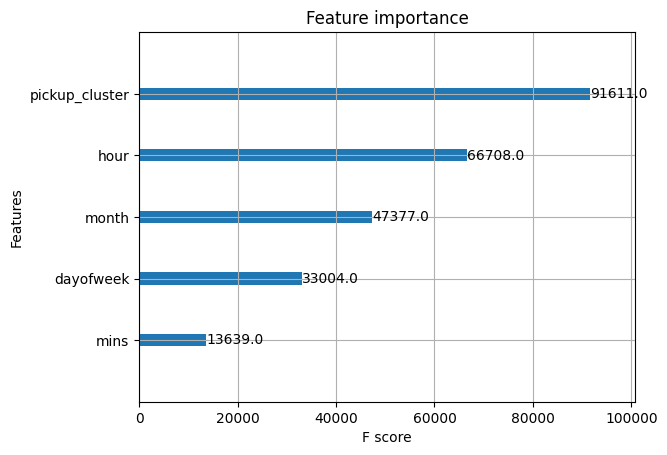

In [ ]:
plot_importance(model)

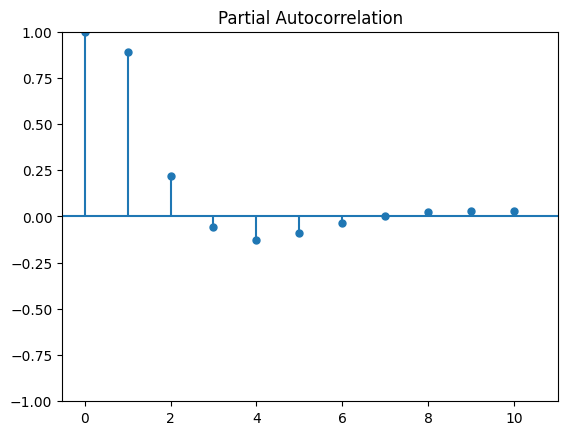

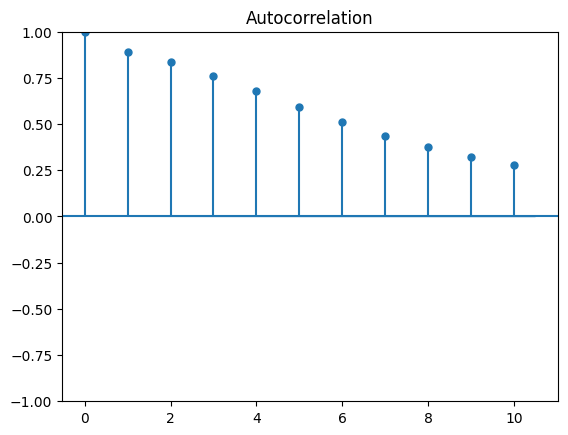

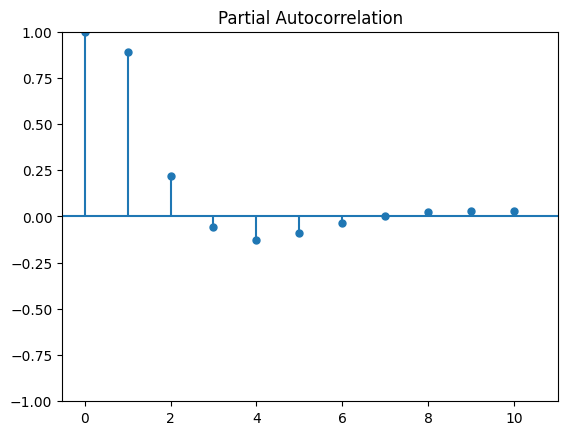

In [ ]:
plot_acf(df_train['request_count'], lags=10)
plot_pacf(df_train['request_count'], lags=10)

In [ ]:
df_test = df_test.sort_values(by=['pickup_cluster', 'ts']).drop_duplicates(subset=['ts','pickup_cluster'])
temp = pd.concat([df_train,df_test])
temp = temp.sort_values(by=['pickup_cluster', 'ts']).drop_duplicates(subset=['ts','pickup_cluster'])
temp = temp.set_index(['ts', 'pickup_cluster', 'mins','hour', 'month', 'quarter', 'dayofweek'])

temp['lag_1'] = temp.groupby(level=['pickup_cluster'])['request_count'].shift(1)
temp['lag_2'] = temp.groupby(level=['pickup_cluster'])['request_count'].shift(2)
temp['lag_3'] = temp.groupby(level=['pickup_cluster'])['request_count'].shift(3)
temp.head(15)

,,,,,,,request_count,lag_1,lag_2,lag_3
ts,pickup_cluster,mins,hour,month,quarter,dayofweek,,,,
2020-03-26 00:00:00,0,0,0,3,1,3,0,NaN,NaN,NaN
2020-03-26 00:30:00,0,30,0,3,1,3,0,0.0,NaN,NaN
2020-03-26 01:00:00,0,0,1,3,1,3,0,0.0,0.0,NaN
2020-03-26 01:30:00,0,30,1,3,1,3,0,0.0,0.0,0.0
2020-03-26 02:00:00,0,0,2,3,1,3,1,0.0,0.0,0.0
2020-03-26 02:30:00,0,30,2,3,1,3,0,1.0,0.0,0.0
2020-03-26 03:00:00,0,0,3,3,1,3,0,0.0,1.0,0.0
2020-03-26 03:30:00,0,30,3,3,1,3,0,0.0,0.0,1.0
2020-03-26 04:00:00,0,0,4,3,1,3,0,0.0,0.0,0.0


In [ ]:
temp = temp.reset_index(drop = False).dropna()
temp = temp[['ts', 'pickup_cluster', 'mins','hour', 'month', 'quarter',
       'dayofweek', 'lag_1', 'lag_2', 'lag_3',
        'request_count']]

In [ ]:
train1 = temp[temp.ts.dt.day <=23]
test1 = temp[temp.ts.dt.day >23]

X = train1.iloc[:, 1:-1]
y = train1.iloc[:, -1]
X_test = test1.iloc[:, 1:-1]
y_test = test1.iloc[:, -1]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 500, random_state=0, n_jobs = -1)
regressor.fit(X,y)
print("RMSE TRAIN: {}, RMSE TEST:{}".format(sqrt(mean_squared_error(y, regressor.predict(X))), metrics_calculate(regressor)))

NameError: ignored